# Intuitive Learning Screen Research

Started: 2026-05-15

## Feature Hypothesis

### Idea

Refactor the current learning screen so users learn by touching and hearing the currently displayed Dub Techno idea instead of reading dense explanations.

### Target user

- Android-first electronic music producer
- Beginner or intermediate with limited music theory vocabulary
- Wants to understand why a vibe works and then reproduce it in a DAW

### Problem

The current `IntuitiveLearningPanel` exposes pulse, bass motion, scale color, and sound layers, but it is still text-heavy. It explains the result rather than making the user discover it through a small interaction loop.

### MVP scope

- Keep only one primary learning focus at a time: Pulse, Bass, Chord, or Sound
- Add direct audition controls for the focused item
- Add A/B compare: original vs one suggested mutation
- Replace long explanations with one outcome word and one short reason
- Reuse existing suggestion, audition, DAW-view, and learning cue data

### Non-goals

- Full course system
- Gamified scoring
- Account/progress tracking
- Ear-training correctness detection
- Generic music theory encyclopedia

### Research questions

1. Which interaction patterns make music-learning tools feel intuitive?
2. What should Vibe-to-MIDI borrow from adjacent apps without copying their full scope?
3. What should be removed from the current learning screen for a minimal MVP?
4. Should the next implementation be a new screen or a refactor of `IntuitiveLearningPanel`?


## Source Notes

- https://learningmusic.ableton.com/the-playground.html — Ableton Learning Music uses a playground model where users experiment with beats, notes, scales, chords, and structures after learning the basics.
- https://learningmusic.ableton.com/notes-and-scales/play-with-notes-and-scales.html — Ableton lets users try patterns with different tonic/scale settings and hear synced beats, supporting immediate sound comparison.
- https://www.ableton.com/en/blog/learn-music-in-your-browser/ — Ableton positions Learning Music as interactive, browser-based basics for beats, melodies, basslines, chords, and song structure, with export to Ableton Live Set.
- https://www.ableton.com/en/live/learn-live/instruments-effects/ — Ableton groups Learning Music and Learning Synths as fundamentals learned at the user's pace with browser tools.
- https://audiblegenius.com/buildingblocks/ — Building Blocks emphasizes learn-by-doing, piano-roll-native theory for DAW musicians, and MIDI export to a DAW.
- https://support.audiblegenius.com/en_US/getting-started/what-devices-and-browsers-can-i-use — Building Blocks explicitly treats phones as too small for DAW-power workflows, suggesting Vibe-to-MIDI should simplify heavily on mobile.
- https://melodics.com/how-it-works — Melodics highlights instant feedback and challenge ramping, useful as a pattern even if Vibe-to-MIDI does not score user input yet.
- https://support.melodics.com/en/articles/6777074-navigating-your-learning-with-melodics — Melodics separates Guided and Explore approaches, a useful model for Vibe-to-MIDI's Listen / Learn / MIDI modes.
- https://www.skoove.com/blog/choose-your-method/ — Skoove markets interactive lessons and real-time feedback, validating the value of compact feedback loops.
- https://www.hooktheory.com/support/hookpad — Hookpad combines chord staff, piano-roll-like editing, looping, and export, validating DAW-oriented visual learning.
- https://www.hooktheory.com/faq — Hookpad aims to serve users from beginners to EDM composers and labels notes around the piano-roll view, supporting direct note visibility.
- https://amt-lab.org/reviews/2019/2/chrome-music-lab — Chrome Music Lab is described as easy, intuitive, no-login, no-instrument-required learning through hands-on experiments.


## Data / Analysis


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

feature_dir = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path('research/features/2026-05-15_intuitive-learning-screen')
figures_dir = feature_dir / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

products = pd.DataFrame([
    {
        'product': 'Ableton Learning Music',
        'category': 'interactive music basics',
        'primary_pattern': 'playground after concept',
        'direct_audio': True,
        'minimal_text': True,
        'ab_compare': True,
        'daw_context': True,
        'mobile_fit': 'medium',
        'takeaway': 'Let the user change one musical variable and hear the result immediately.',
    },
    {
        'product': 'Ableton Learning Synths',
        'category': 'interactive sound design basics',
        'primary_pattern': 'touch a control, hear a sound',
        'direct_audio': True,
        'minimal_text': True,
        'ab_compare': True,
        'daw_context': True,
        'mobile_fit': 'medium',
        'takeaway': 'Sound design concepts should be represented as small controls, not paragraphs.',
    },
    {
        'product': 'Audible Genius Building Blocks',
        'category': 'DAW-native theory course',
        'primary_pattern': 'piano-roll challenges',
        'direct_audio': True,
        'minimal_text': False,
        'ab_compare': True,
        'daw_context': True,
        'mobile_fit': 'low',
        'takeaway': 'Piano-roll-native learning is ideal, but mobile needs a smaller interaction surface.',
    },
    {
        'product': 'Melodics',
        'category': 'instrument practice',
        'primary_pattern': 'guided vs explore plus feedback',
        'direct_audio': True,
        'minimal_text': True,
        'ab_compare': False,
        'daw_context': False,
        'mobile_fit': 'medium',
        'takeaway': 'Separate a guided path from free exploration; keep feedback immediate.',
    },
    {
        'product': 'Skoove',
        'category': 'piano learning',
        'primary_pattern': 'real-time feedback lesson',
        'direct_audio': True,
        'minimal_text': True,
        'ab_compare': False,
        'daw_context': False,
        'mobile_fit': 'medium',
        'takeaway': 'Feedback matters, but Vibe-to-MIDI should avoid correctness scoring until input exists.',
    },
    {
        'product': 'Hookpad',
        'category': 'songwriting / theory editor',
        'primary_pattern': 'chord staff plus piano roll',
        'direct_audio': True,
        'minimal_text': False,
        'ab_compare': True,
        'daw_context': True,
        'mobile_fit': 'low',
        'takeaway': 'Use note labels and chord context, but avoid desktop-editor density.',
    },
    {
        'product': 'Chrome Music Lab',
        'category': 'hands-on music experiments',
        'primary_pattern': 'no-login experiment tiles',
        'direct_audio': True,
        'minimal_text': True,
        'ab_compare': True,
        'daw_context': False,
        'mobile_fit': 'high',
        'takeaway': 'Use icon-like, low-friction controls; make first interaction obvious.',
    },
])

products


,product,category,primary_pattern,direct_audio,minimal_text,ab_compare,daw_context,mobile_fit,takeaway
0,Ableton Learning Music,interactive music basics,playground after concept,True,True,True,True,medium,Let the user change one musical variable and h...
1,Ableton Learning Synths,interactive sound design basics,"touch a control, hear a sound",True,True,True,True,medium,Sound design concepts should be represented as...
2,Audible Genius Building Blocks,DAW-native theory course,piano-roll challenges,True,False,True,True,low,"Piano-roll-native learning is ideal, but mobil..."
3,Melodics,instrument practice,guided vs explore plus feedback,True,True,False,False,medium,Separate a guided path from free exploration; ...
4,Skoove,piano learning,real-time feedback lesson,True,True,False,False,medium,"Feedback matters, but Vibe-to-MIDI should avoi..."
5,Hookpad,songwriting / theory editor,chord staff plus piano roll,True,False,True,True,low,"Use note labels and chord context, but avoid d..."
6,Chrome Music Lab,hands-on music experiments,no-login experiment tiles,True,True,True,False,high,"Use icon-like, low-friction controls; make fir..."


PosixPath('/Users/asami/develop/art/Vibe-to-MIDI/research/features/2026-05-15_intuitive-learning-screen/figures/learning_interaction_patterns.png')

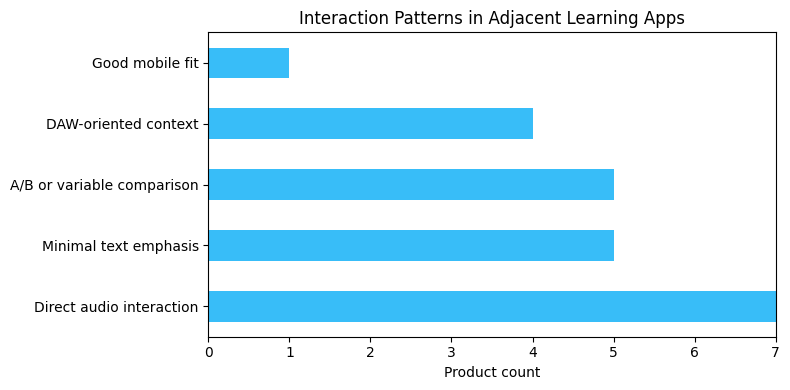

In [2]:
signals = pd.DataFrame({
    'signal': [
        'Direct audio interaction',
        'Minimal text emphasis',
        'A/B or variable comparison',
        'DAW-oriented context',
        'Good mobile fit',
    ],
    'count': [
        int(products['direct_audio'].sum()),
        int(products['minimal_text'].sum()),
        int(products['ab_compare'].sum()),
        int(products['daw_context'].sum()),
        int((products['mobile_fit'] == 'high').sum()),
    ],
})

ax = signals.plot.barh(x='signal', y='count', legend=False, color='#38bdf8', figsize=(8, 4))
ax.set_title('Interaction Patterns in Adjacent Learning Apps')
ax.set_xlabel('Product count')
ax.set_ylabel('')
ax.set_xlim(0, len(products))
plt.tight_layout()
chart_path = figures_dir / 'learning_interaction_patterns.png'
plt.savefig(chart_path, dpi=160)
chart_path


![Interaction patterns](../figures/learning_interaction_patterns.png)


In [3]:
current_screen_inventory = pd.DataFrame([
    {'area': 'Layer chips', 'current_value': 'quick summary', 'keep': True, 'change': 'Reduce to one active focus selector: Pulse / Bass / Chord / Sound.'},
    {'area': 'Try this card', 'current_value': 'text suggestion', 'keep': True, 'change': 'Turn into an A/B compare control with Original and Mutated buttons.'},
    {'area': 'What changed card', 'current_value': 'paragraph result', 'keep': False, 'change': 'Replace with one outcome word plus one short sentence after the user taps compare.'},
    {'area': 'Pulse map', 'current_value': '16 visible cells', 'keep': True, 'change': 'Make cells tappable/audible; show only focused pulse when Pulse is active.'},
    {'area': 'Bass motion', 'current_value': 'bar chart plus text', 'keep': True, 'change': 'Make notes tappable; add Original vs Simple bass comparison.'},
    {'area': 'Scale color', 'current_value': 'all notes plus reason', 'keep': 'narrow', 'change': 'Move to Chord focus or collapse; show only root, color note, and chord notes.'},
    {'area': 'Sound layers', 'current_value': 'chips with descriptors', 'keep': 'narrow', 'change': 'Show only active layer controls: kick, bass, noise, stab; use audition instead of long descriptors.'},
])

current_screen_inventory


,area,current_value,keep,change
0,Layer chips,quick summary,True,Reduce to one active focus selector: Pulse / B...
1,Try this card,text suggestion,True,Turn into an A/B compare control with Original...
2,What changed card,paragraph result,False,Replace with one outcome word plus one short s...
3,Pulse map,16 visible cells,True,Make cells tappable/audible; show only focused...
4,Bass motion,bar chart plus text,True,Make notes tappable; add Original vs Simple ba...
5,Scale color,all notes plus reason,narrow,Move to Chord focus or collapse; show only roo...
6,Sound layers,chips with descriptors,narrow,"Show only active layer controls: kick, bass, n..."


In [4]:
mvp_options = pd.DataFrame([
    {
        'option': 'Refactor current Learn panel into focus cards',
        'implementation_cost': 2,
        'learning_value': 5,
        'mobile_fit': 5,
        'risk': 2,
        'recommendation': 'Build first',
    },
    {
        'option': 'Add full guided course progression',
        'implementation_cost': 5,
        'learning_value': 4,
        'mobile_fit': 3,
        'risk': 5,
        'recommendation': 'Defer',
    },
    {
        'option': 'Add correctness scoring / ear training',
        'implementation_cost': 5,
        'learning_value': 4,
        'mobile_fit': 3,
        'risk': 5,
        'recommendation': 'Defer until input exists',
    },
    {
        'option': 'Build separate music-theory encyclopedia',
        'implementation_cost': 4,
        'learning_value': 2,
        'mobile_fit': 2,
        'risk': 4,
        'recommendation': 'Reject for MVP',
    },
])

mvp_options['score'] = mvp_options['learning_value'] + mvp_options['mobile_fit'] - mvp_options['implementation_cost'] - mvp_options['risk']
mvp_options.sort_values('score', ascending=False)


,option,implementation_cost,learning_value,mobile_fit,risk,recommendation,score
0,Refactor current Learn panel into focus cards,2,5,5,2,Build first,6
1,Add full guided course progression,5,4,3,5,Defer,-3
2,Add correctness scoring / ear training,5,4,3,5,Defer until input exists,-3
3,Build separate music-theory encyclopedia,4,2,2,4,Reject for MVP,-4


## Decision Summary

### Recommendation: Build, but narrow

Refactor the existing learning screen rather than adding a new course or encyclopedia. The new screen should minimize static text and make one variable audible and touchable at a time.

### Evidence

- Adjacent tools consistently emphasize immediate audio interaction. Every source in the product matrix supports direct audio feedback.
- The strongest DAW-oriented tools use piano-roll or chord-staff concepts, but those patterns become dense on phones. Vibe-to-MIDI should use a smaller mobile-native subset.
- Tools like Ableton Learning Music, Learning Synths, and Chrome Music Lab suggest that intuitive learning starts with visible controls and immediate sound, not long explanations.
- Melodics and Skoove validate feedback loops, but Vibe-to-MIDI should defer correctness scoring because the app does not yet capture user performance input.
- Building Blocks validates DAW-native theory learning, but its own device guidance suggests phone screens are too small for full DAW-power workflows.

### Proposed MVP redesign

Replace the current long `IntuitiveLearningPanel` with a focused interaction model:

1. **Focus selector**: `Pulse`, `Bass`, `Chord`, `Sound`.
2. **One-line goal**: e.g. `Hear why this loop feels deeper`.
3. **A/B controls**: `Original` and `Try change`, each with play buttons.
4. **Tiny visual**: one 16-step strip, one bass motion strip, or one chord note row depending on focus.
5. **Result chip**: one word such as `more spacious`, `more locked`, or `darker`.
6. **One short reason**: max one sentence; no paragraph stack.

### Remove or hide in MVP

- Always-visible `What changed?` paragraph card
- Full scale note list when the focus is not chord/scale
- Full sound layer descriptor grid
- Multiple explanation sections on the same screen
- Text-only `Try this` instruction with no audio action

### Implementation direction

- Keep `getLearningCue` as a source of learning facts, but add a new view model such as `buildLearningFocusView(suggestion, focus)`.
- Reuse `playAuditionNote` / `playAuditionChord` and preview controls for audible A/B interactions.
- Start with two focus modes: `Pulse` and `Bass`. Add `Chord` after the chord-learning panel stabilizes. Add `Sound` after layer audition is reliable.
- Preserve the current Learn route and replace internal presentation instead of adding navigation complexity.

### Risks

- A/B mutation must not imply that one option is objectively better; label it as a feel change.
- If too many controls appear at once, the screen will recreate the current density problem.
- Mobile tap targets and text fitting need explicit verification on small Android widths.
- Audio preview and audition state must not overlap confusingly.

### Next step

Implement a UI spike for `Pulse` and `Bass` focus cards only. Confirm that the screen can explain one musical idea through listen/compare before expanding to chord and sound.

### Notebook execution status

Executed successfully with `research/.venv/bin/jupyter nbconvert --to notebook --execute` on 2026-05-15. Generated `figures/learning_interaction_patterns.png`.


## Open Questions

- Should the first focus default be based on the selected vibe's strongest differentiator, or always start with Pulse?
- Should A/B mutation temporarily alter the live preview, or play a short isolated demonstration only?
- How much Japanese copy is needed in the MVP, given English remains primary?
- Should `Sound` focus wait until kick/noise/stab audition controls are more complete?
- What is the smallest Android width that must be visually verified before merging the UI refactor?
